# notes

description:
    Load the UV scan csv data in UV_data/file.csv, clean headers, parse numeric columns, and graph trace (abs vs wavelength nm) 

requirements:
    pandas, matplotlib

# imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels
from pathlib import Path

# file

In [3]:
csvfile = "20260323 TigE UV scan.csv"
# print(f"Current csvfile: {csvfile}")
DATA_DIR = Path(csvfile).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILE = DATA_DIR / csvfile
# print(f"Reading data from: {CSV_FILE}")

# read raw csv


In [4]:
# first row has header groups 
# second row has headers 
# third row data starts

# forward fill header blanks bc output format is missing complete first row column labels
headers = pd.read_csv(CSV_FILE, nrows=2, header=None)
sample_header = headers.iloc[0].ffill()
data_header = headers.iloc[1]
header = sample_header.astype(str) + "." + data_header.astype(str)
print("Headers to copy into column selection")
print(header)

# read in data rows 
uv_scan_raw = pd.read_csv(
    CSV_FILE,
    sep=",",    # whitespace sep (tabs + spaces)
    skiprows=2,
    header=None,   # we already dealt with this
    # usecols=[0,1,2,3],
    engine="python",
    encoding="utf-8",
    na_values=["", '""'],
)

# convert to numeric
uv_scan_df = uv_scan_raw.apply(pd.to_numeric, errors="coerce")
# add headers back in 
uv_scan_df.columns = header

Headers to copy into column selection
0    Baseline 100%T.Wavelength (nm)
1                Baseline 100%T.Abs
2          TigE 200.Wavelength (nm)
3                      TigE 200.Abs
4                               NaN
dtype: str


In [5]:
## select wavelength, baseline, and abs columns 
cols_to_choose = ['Baseline 100%T.Wavelength (nm)',  # wavelengths for x axis 
                    'Baseline 100%T.Abs',  # baseline absorbance values 
                    'TigE 200.Abs'    # enzyme(s) of interest - choose the .Abs columns 
                  ]
uv_scan_df = uv_scan_df[cols_to_choose]

# print("sample data:")
# print(uv_scan_df.head())

print("copy+paste dictionary into legend section to edit legend labels\n")
print("label_map = {")
for col in uv_scan_df.columns[1:]:
    print(f"    '{col}': '{col}',")
print("}")

copy+paste dictionary into legend section to edit legend labels

label_map = {
    'Baseline 100%T.Abs': 'Baseline 100%T.Abs',
    'TigE 200.Abs': 'TigE 200.Abs',
}


# plot and output

In [6]:
## set variables 
# paste in dictionary and edit right hand side for legend 
# example: 'Baseline 100%T.Abs': 'Baseline' to change legend label to "Baseline"
label_map = {
    'Baseline 100%T.Abs': 'Baseline',
    'TigE 200.Abs': 'TigE',
}

# change colors 
color_base = "black"
color_enz = "tab:blue"

# axes and fig size 
abs_max = 2.25
fig_width = 16 * 0.5 
fig_height = 10 * 0.5 

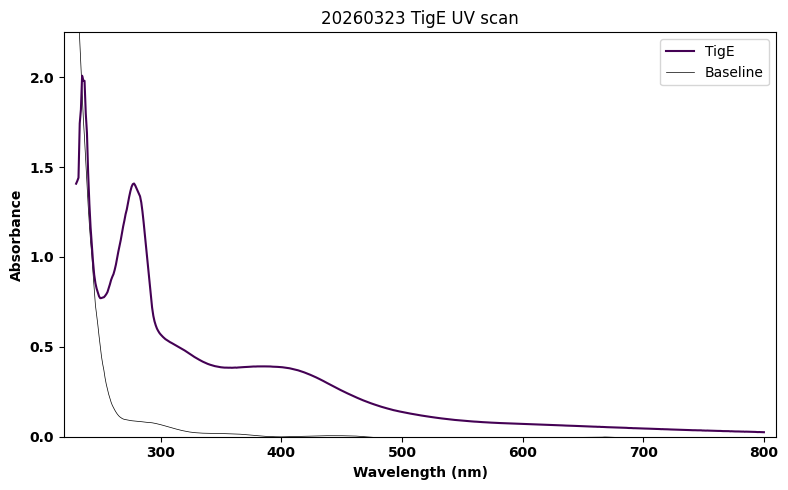

A280: 1.4
A400: 0.4
A280/A400 ratio: 3.570


In [10]:
## plot
# set x and y 
x = uv_scan_df["Baseline 100%T.Wavelength (nm)"]  # wavelengths for x axis 
y_base = uv_scan_df["Baseline 100%T.Abs"]  # baseline for first y 

# set axes 
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Absorbance", color=color_base)
ax.set_ylim(0, abs_max)
ax.set_xlim([220, 810])

# plot baseline 
ax.plot(x, y_base, color=color_base, linewidth=0.5, label=label_map.get(uv_scan_df.columns[1], uv_scan_df.columns[1]))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5)) # major ticks on multiples of MultipleLocator(x)
ax.tick_params(axis="y", colors=color_base)

# plot enzyme(s) of interest
n_enz = len(uv_scan_df.columns) - 2  # number of enzyme columns
cmap = plt.cm.viridis  # pick a colormap
for i, col in enumerate(uv_scan_df.columns[2:]):
    color = cmap(i / max(n_enz - 1, 1))  # normalize index
    ax.plot(x, uv_scan_df[col], color=color, label=label_map.get(col, col))

# title should match csv file for consistency 
plt.title(f"{csvfile[:-4]}")

# ax.grid(True, axis="x", alpha=0.3)  # gridlines 
fig.tight_layout()

# reorder legend 
handles, labels = plt.gca().get_legend_handles_labels()
order = [*range(1, len(handles)), 0]
plt.legend([handles[label] for label in order],
           [labels[label] for label in order], 
           prop={'weight': 'normal'})

# finished product 
# save png file, png name matches csv and title 
out_png = DATA_DIR / f"{csvfile[:-4]}"
fig.savefig(out_png, dpi=1500)
plt.show()

# find A280, A400, and A280/400 ratio 
a280_id = (uv_scan_df.iloc[:, 0] - 280).abs().idxmin()
a280 = uv_scan_df.iloc[a280_id, 2]
a400_id = (uv_scan_df.iloc[:, 0] - 400).abs().idxmin()
a400 = uv_scan_df.iloc[a400_id, 2]
ratio = a280 / a400

# a280 = uv_scan_df.loc[uv_scan_df["Baseline 100%T.Wavelength (nm)"] >= 280.0 and uv_scan_df["Baseline 100%T.Wavelength (nm)"] <= 280.1, "TigE 200.Abs"].values[0]
# a400 = uv_scan_df.loc[uv_scan_df["Baseline 100%T.Wavelength (nm)"] >= 400, "TigE 200.Abs"].values[0]
# ratio = a280 / a400
print(f"A280: {a280:.1f}")
print(f"A400: {a400:.1f}")
print(f"A280/A400 ratio: {ratio:.3f}")